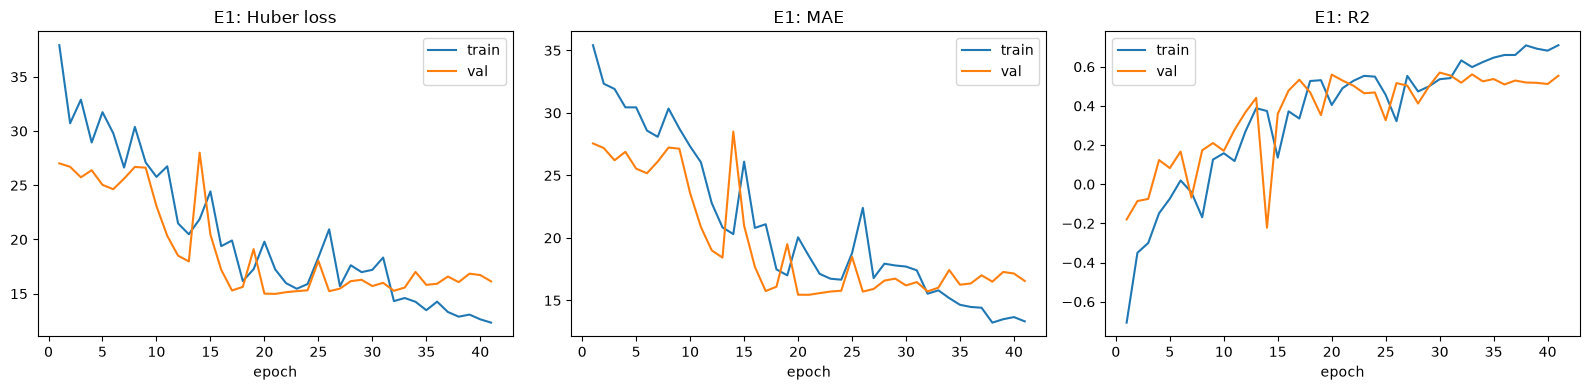

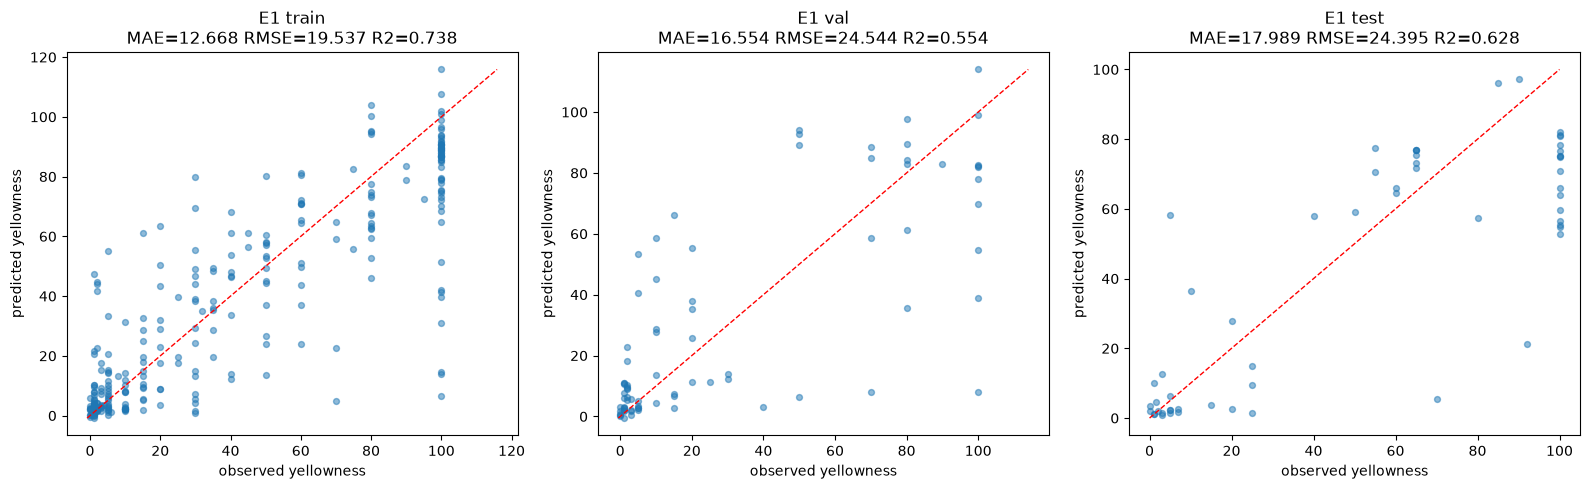

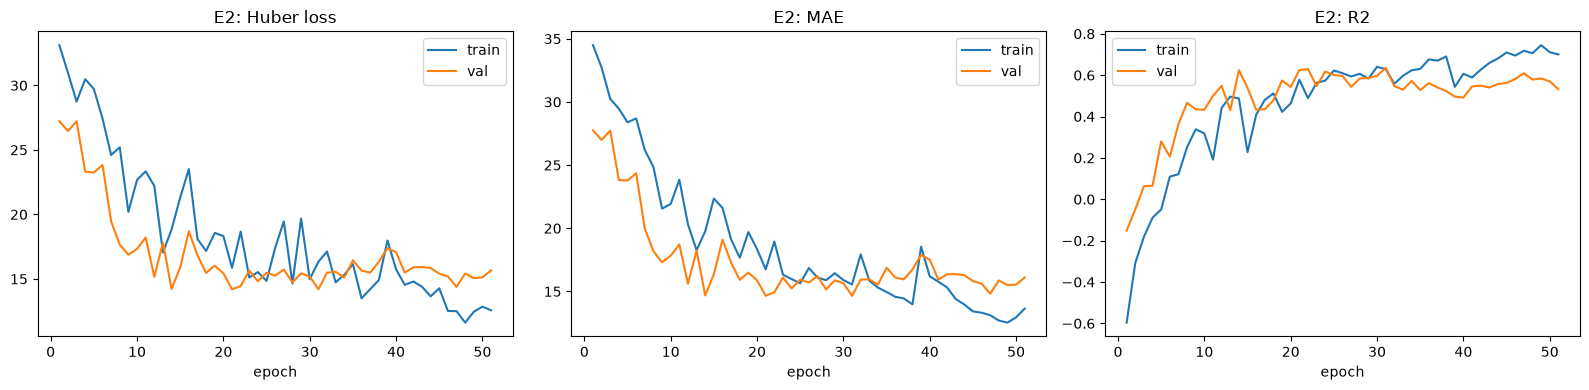

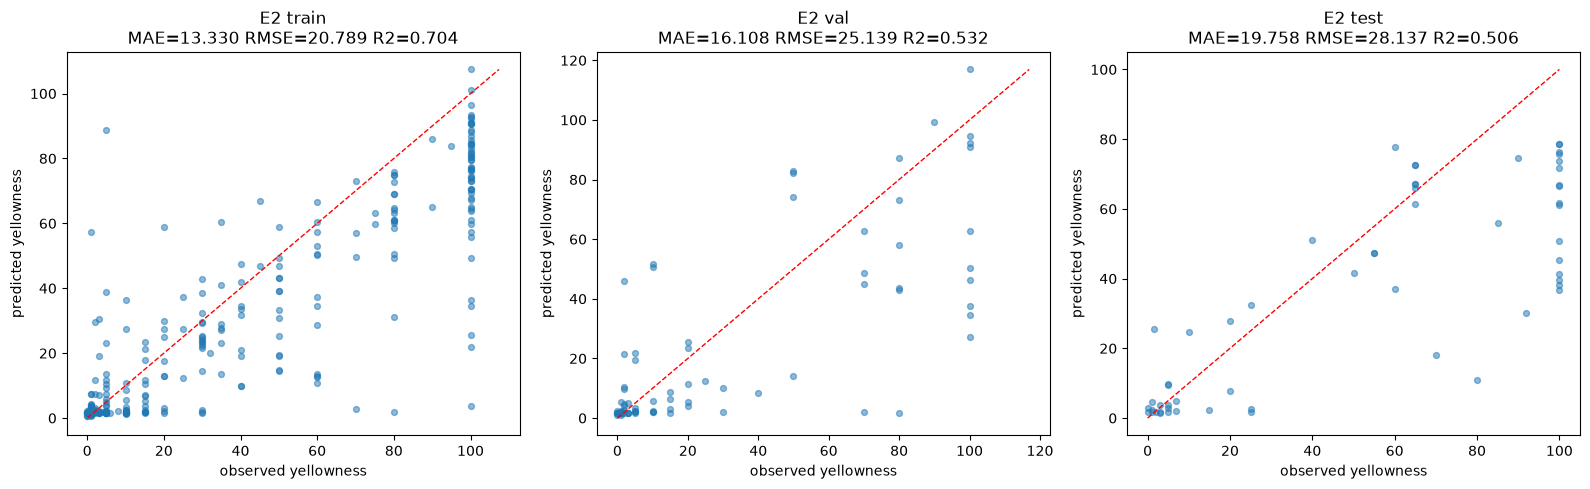

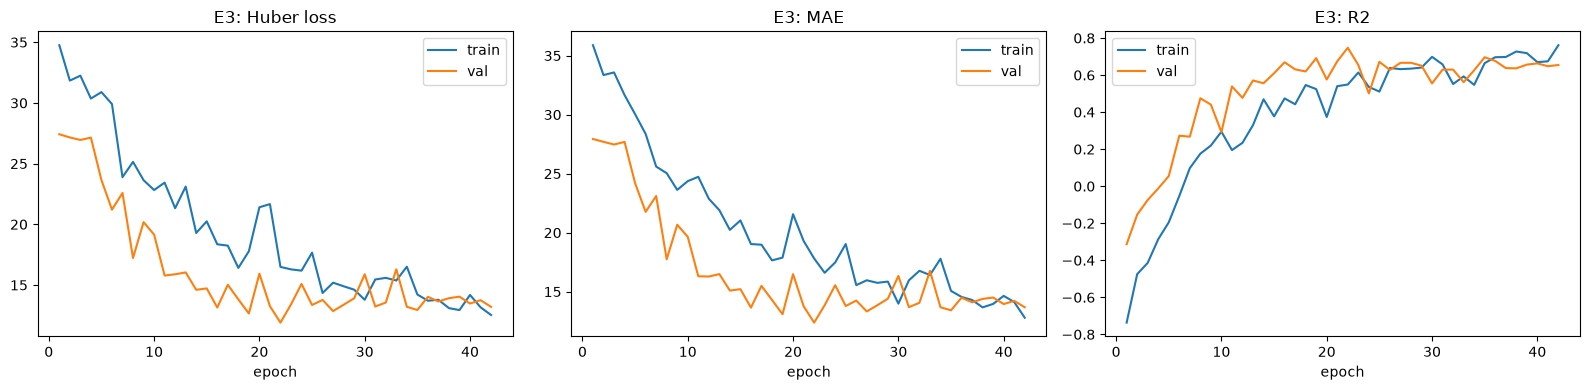

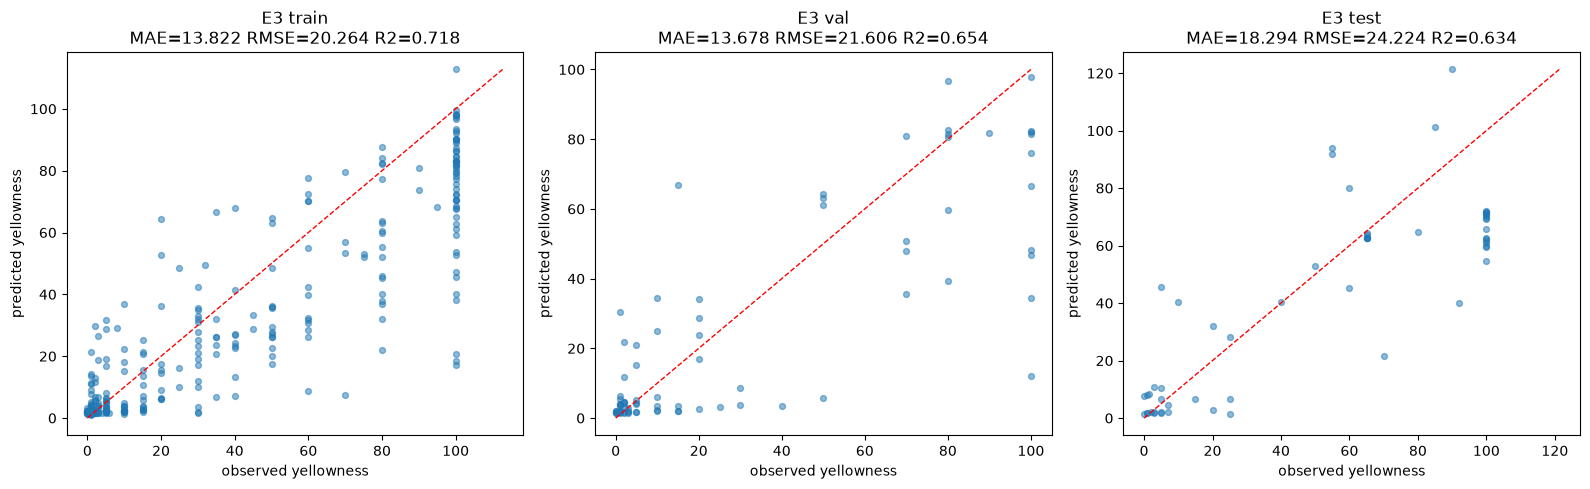

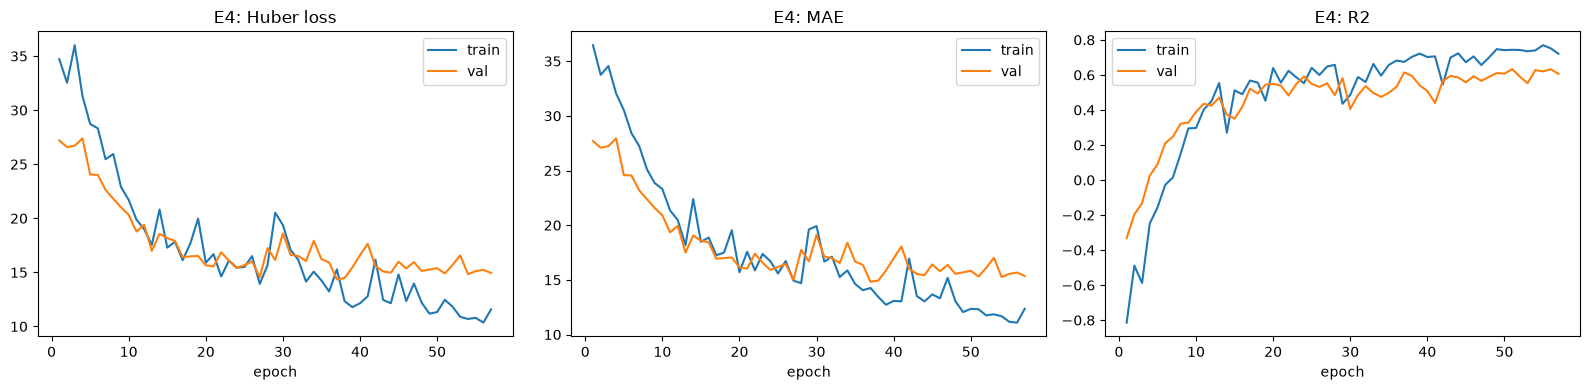

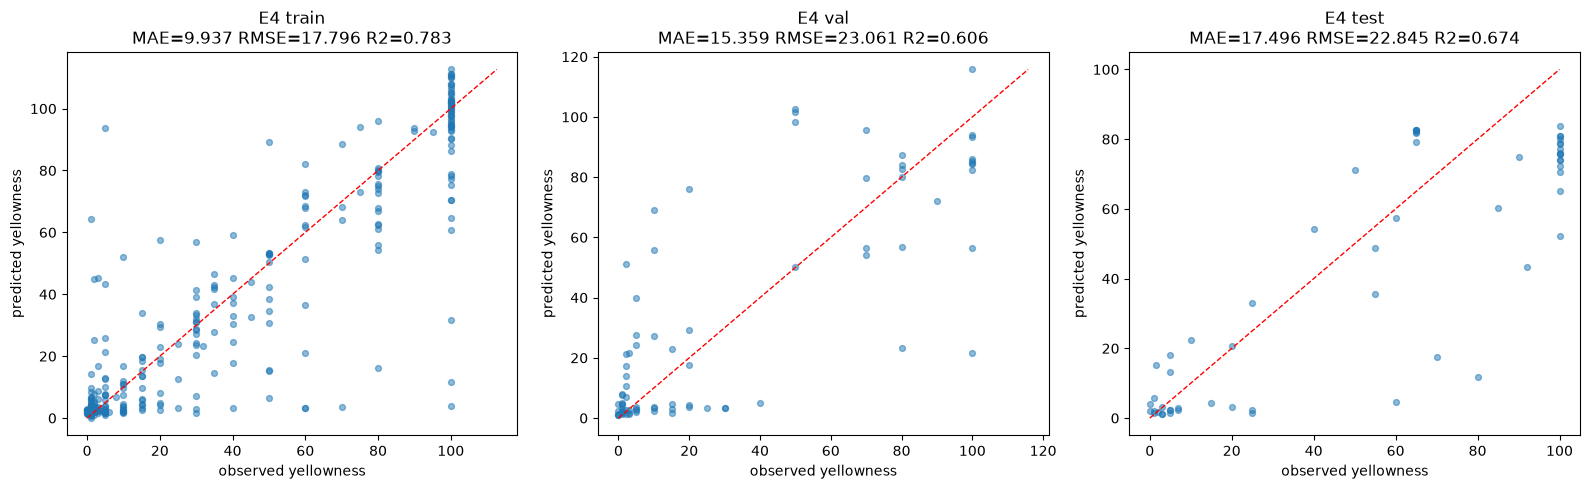

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EXPERIMENT_NAMES = ["E1", "E2", "E3", "E4"]
SPLIT_NAMES = ["train", "val", "test"]

from pathlib import Path
PAPER_OUTPUT_DIR = Path(r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\DL_training_results")
PLOTS_OUTPUT_DIR = PAPER_OUTPUT_DIR / "plots"
PLOTS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _exp_dir(exp_name: str) -> Path:
    return PAPER_OUTPUT_DIR / exp_name


def load_history(exp_name: str) -> pd.DataFrame:
    path = _exp_dir(exp_name) / "history.csv"
    if not path.exists():
        raise FileNotFoundError(f"history.csv not found for {exp_name}: {path}")
    return pd.read_csv(path)


def load_predictions(exp_name: str, split: str) -> pd.DataFrame:
    path = _exp_dir(exp_name) / f"predictions_{split}.csv"
    if not path.exists():
        raise FileNotFoundError(f"predictions_{split}.csv not found for {exp_name}: {path}")
    return pd.read_csv(path)


def plot_loss_and_metric_curves(exp_name: str) -> None:
    hist = load_history(exp_name)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(hist["epoch"], hist["train_loss"], label="train")
    axes[0].plot(hist["epoch"], hist["validation_loss"], label="val")
    axes[0].set_title(f"{exp_name}: Huber loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(hist["epoch"], hist["train_MAE"], label="train")
    axes[1].plot(hist["epoch"], hist["validation_MAE"], label="val")
    axes[1].set_title(f"{exp_name}: MAE")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    axes[2].plot(hist["epoch"], hist["train_R2"], label="train")
    axes[2].plot(hist["epoch"], hist["validation_R2"], label="val")
    axes[2].set_title(f"{exp_name}: R2")
    axes[2].set_xlabel("epoch")
    axes[2].legend()

    plt.tight_layout()

    save_path = PLOTS_OUTPUT_DIR / f"{exp_name}_training_curves.pdf"
    fig.savefig(save_path, format="pdf", bbox_inches="tight")

    plt.show()
    plt.close(fig)


def plot_predicted_vs_observed(exp_name: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, split in zip(axes, SPLIT_NAMES):
        preds = load_predictions(exp_name, split)
        y_true = preds["y_true"].to_numpy()
        y_pred = preds["y_pred"].to_numpy()

        mae = float(np.mean(np.abs(y_true - y_pred)))
        rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

        lo = float(min(y_true.min(), y_pred.min()))
        hi = float(max(y_true.max(), y_pred.max()))

        ax.scatter(y_true, y_pred, alpha=0.5, s=18)
        ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
        ax.set_title(
            f"{exp_name} {split}\n"
            f"MAE={mae:.3f} RMSE={rmse:.3f} R2={r2:.3f}"
        )
        ax.set_xlabel("observed yellowness")
        ax.set_ylabel("predicted yellowness")

    plt.tight_layout()

    save_path = PLOTS_OUTPUT_DIR / f"{exp_name}_predicted_vs_observed.pdf"
    fig.savefig(save_path, format="pdf", bbox_inches="tight")

    plt.show()
    plt.close(fig)


for exp_name in EXPERIMENT_NAMES:
    plot_loss_and_metric_curves(exp_name)
    plot_predicted_vs_observed(exp_name)

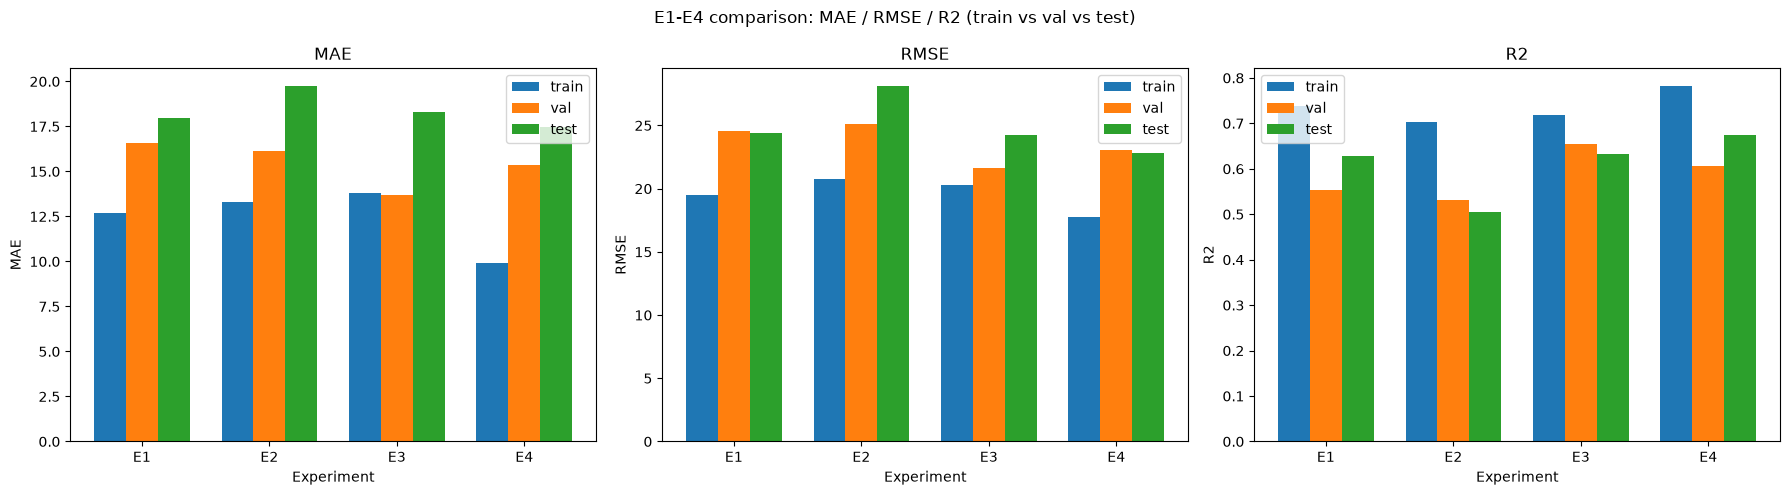

In [5]:
def plot_metric_comparison(comparison_df: pd.DataFrame) -> None:
    """Grouped bar chart comparing MAE, RMSE, R2 across E1-E4 for train/val/test."""
    df = comparison_df.set_index("experiment").loc[EXPERIMENT_NAMES]
    metrics = ["MAE", "RMSE", "R2"]

    # Output directory
    PLOTS_OUTPUT_DIR = PAPER_OUTPUT_DIR / "plots"
    PLOTS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    x = np.arange(len(EXPERIMENT_NAMES))
    width = 0.25

    for ax, metric in zip(axes, metrics):
        for i, split in enumerate(SPLIT_NAMES):
            values = df[f"{split}_{metric}"].to_numpy()
            ax.bar(
                x + (i - 1) * width,
                values,
                width,
                label=split
            )

        ax.set_xticks(x)
        ax.set_xticklabels(EXPERIMENT_NAMES)
        ax.set_title(metric)
        ax.set_xlabel("Experiment")
        ax.set_ylabel(metric)
        ax.legend()

    fig.suptitle(
        "E1-E4 comparison: MAE / RMSE / R2 (train vs val vs test)"
    )

    plt.tight_layout()

    # Save as vector PDF for the report
    save_path = PLOTS_OUTPUT_DIR / "E1-E4_metric_comparison.pdf"
    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


paper_repr_comparison_df = pd.read_csv(
    PAPER_OUTPUT_DIR / "comparison_table.csv"
)

plot_metric_comparison(paper_repr_comparison_df)